In [ ]:
# E-commerce Sales Analysis using Python

# Objective: To analyze sales data and generate actionable business insights.

# Tools Used: Python, Pandas, Matplotlib, Seaborn

In [2]:
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv('sample_data.csv')
df.columns

Index(['index', 'Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel ',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by', 'Unnamed: 22'],
      dtype='str')

In [4]:
df.info()

<class 'pandas.DataFrame'>
RangeIndex: 1000 entries, 0 to 999
Data columns (total 24 columns):
 #   Column              Non-Null Count  Dtype  
---  ------              --------------  -----  
 0   index               1000 non-null   int64  
 1   Order ID            1000 non-null   str    
 2   Date                1000 non-null   str    
 3   Status              1000 non-null   str    
 4   Fulfilment          1000 non-null   str    
 5   Sales Channel       1000 non-null   str    
 6   ship-service-level  1000 non-null   str    
 7   Style               1000 non-null   str    
 8   SKU                 1000 non-null   str    
 9   Category            1000 non-null   str    
 10  Size                1000 non-null   str    
 11  ASIN                1000 non-null   str    
 12  Courier Status      952 non-null    str    
 13  Qty                 1000 non-null   int64  
 14  currency            940 non-null    str    
 15  Amount              940 non-null    float64
 16  ship-city         

In [5]:
df.head()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
0,57259,407-5814732-9549158,05-25-22,Shipped,Amazon,Amazon.in,Expedited,SET254,SET254-KR-NP-XXL,Set,...,INR,886.0,NAVI MUMBAI,MAHARASHTRA,400703.0,IN,NaN,False,NaN,False
1,12804,404-5344837-1564354,04-22-22,Cancelled,Amazon,Amazon.in,Expedited,J0014,J0014-LCD-M,Set,...,INR,1648.0,SULYA,KARNATAKA,574232.0,IN,NaN,False,NaN,NaN
2,113885,402-3398597-4088310,06-11-22,Shipped,Amazon,Amazon.in,Expedited,JNE3757,JNE3757-KR-XXL,kurta,...,INR,487.0,Vadodara,Gujarat,390022.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
3,8954,402-3472022-0065902,04-25-22,Shipped,Amazon,Amazon.in,Expedited,J0198,J0198-TP-XL,Top,...,INR,588.0,GANDHINAGAR,Gujarat,382007.0,IN,NaN,False,NaN,NaN
4,59205,407-2272479-0956311,05-24-22,Shipped,Amazon,Amazon.in,Expedited,SET402,SET402-KR-NP-XXL,Set,...,INR,988.0,Indore,MADHYA PRADESH,452016.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [6]:
df.tail()

,index,Order ID,Date,Status,Fulfilment,Sales Channel,ship-service-level,Style,SKU,Category,...,currency,Amount,ship-city,ship-state,ship-postal-code,ship-country,promotion-ids,B2B,fulfilled-by,Unnamed: 22
995,68710,405-0325936-9459548,05-16-22,Shipped - Delivered to Buyer,Merchant,Amazon.in,Standard,SET183,SET183-KR-DH-M,Set,...,INR,759.0,BENGALURU,KARNATAKA,560072.0,IN,Amazon PLCC Free-Financing Universal Merchant ...,False,Easy Ship,False
996,68002,408-9316152-2961163,05-16-22,Shipped,Amazon,Amazon.in,Expedited,JNE3618,JNE3618-KR-L,kurta,...,INR,399.0,HYDERABAD,TELANGANA,500016.0,IN,NaN,False,NaN,False
997,98218,403-0006868-6998762,06-23-22,Shipped,Amazon,Amazon.in,Expedited,JNE3709,JNE3709-DR-S,Western Dress,...,INR,792.0,BENGALURU,KARNATAKA,560076.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
998,128432,171-8521454-1172349,06-01-22,Shipped,Amazon,Amazon.in,Expedited,SET342,SET342-KR-NP-N-XS,Set,...,INR,850.0,Ranchi,JHARKHAND,834002.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False
999,106836,407-9739622-4380339,06-16-22,Shipped,Amazon,Amazon.in,Expedited,SET328,SET328-KR-NP-XL,Set,...,INR,545.0,THENNALA,KERALA,676508.0,IN,IN Core Free Shipping 2015/04/08 23-48-5-108,False,NaN,False


In [7]:

df.columns = df.columns.str.strip()


df = df.drop(columns=['index', 'Unnamed: 22'])

df.columns

Index(['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
       'ship-service-level', 'Style', 'SKU', 'Category', 'Size', 'ASIN',
       'Courier Status', 'Qty', 'currency', 'Amount', 'ship-city',
       'ship-state', 'ship-postal-code', 'ship-country', 'promotion-ids',
       'B2B', 'fulfilled-by'],
      dtype='str')

In [17]:
df = df[['Order ID', 'Date', 'Status', 'Fulfilment', 'Sales Channel',
         'Category', 'Qty', 'Amount', 'ship-state']]

df.head()

,Order ID,Date,Status,Fulfilment,Sales Channel,Category,Qty,Amount,ship-state
0,407-5814732-9549158,2022-05-25,Shipped,Amazon,Amazon.in,Set,1,886.0,MAHARASHTRA
1,404-5344837-1564354,2022-04-22,Cancelled,Amazon,Amazon.in,Set,1,1648.0,KARNATAKA
2,402-3398597-4088310,2022-06-11,Shipped,Amazon,Amazon.in,kurta,1,487.0,Gujarat
3,402-3472022-0065902,2022-04-25,Shipped,Amazon,Amazon.in,Top,1,588.0,Gujarat
4,407-2272479-0956311,2022-05-24,Shipped,Amazon,Amazon.in,Set,1,988.0,MADHYA PRADESH


In [9]:

df['Date'] = pd.to_datetime(df['Date'])



C:\Users\abhin\AppData\Local\Temp\ipykernel_18256\1827485198.py:1: UserWarning: Could not infer format, so each element will be parsed individually, falling back to `dateutil`. To ensure parsing is consistent and as-expected, please specify a format.
  df['Date'] = pd.to_datetime(df['Date'])


In [10]:

df['Amount'] = pd.to_numeric(df['Amount'], errors='coerce')

In [11]:
df.isnull().sum()



Order ID          0
Date              0
Status            0
Fulfilment        0
Sales Channel     0
Category          0
Qty               0
Amount           60
ship-state        0
dtype: int64

In [12]:
df = df.dropna()

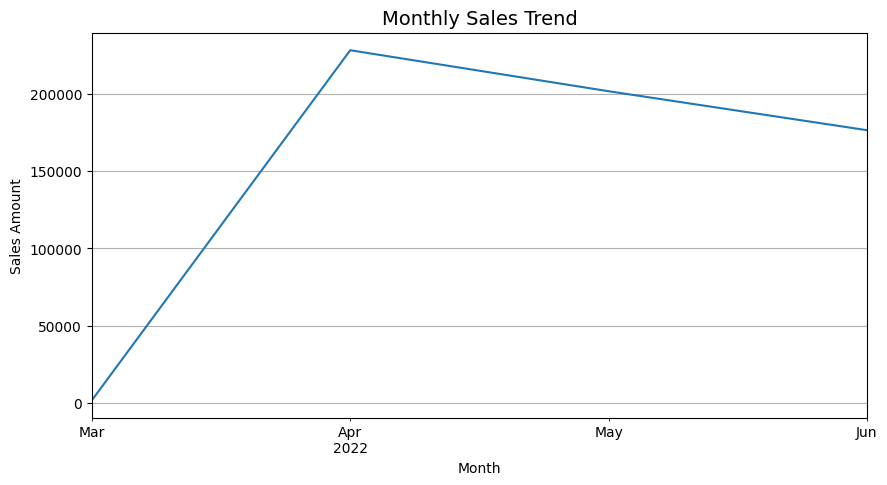

In [13]:
#01: Sales Trend Over Time

# Creating a month column
df['Month'] = df['Date'].dt.to_period('M')

# Grouping by month
monthly_sales = df.groupby('Month')['Amount'].sum()

import matplotlib.pyplot as plt

monthly_sales.plot(figsize=(10,5))
plt.title('Monthly Sales Trend', fontsize=14)
plt.xlabel('Month')
plt.ylabel('Sales Amount')
plt.grid()
plt.show()

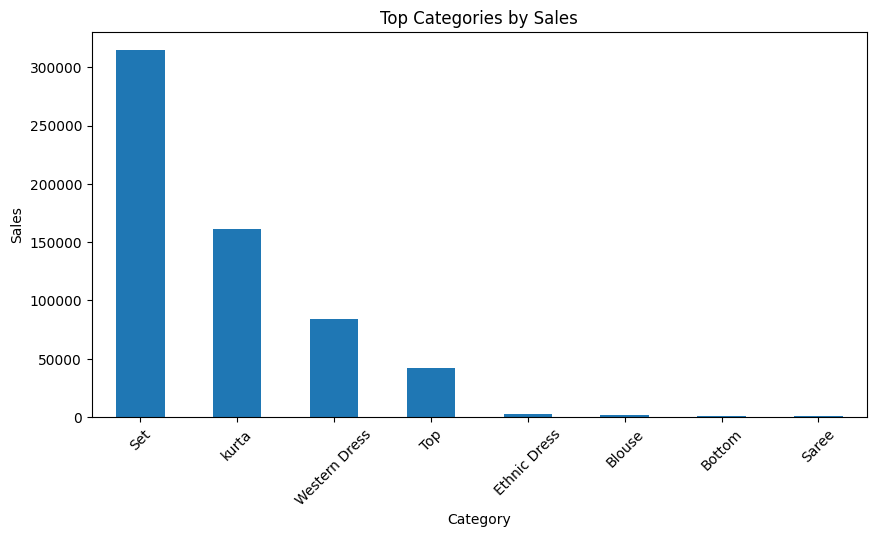

In [19]:
#02: Top Product Categories

category_sales = df.groupby('Category')['Amount'].sum().sort_values(ascending=False)

category_sales.head(10).plot(kind='bar', figsize=(10,5))

plt.title('Top Categories by Sales')
plt.xlabel('Category')
plt.ylabel('Sales')
plt.xticks(rotation=45)
plt.show()

<Axes: title={'center': 'Top 10 States by Sales'}, xlabel='ship-state'>

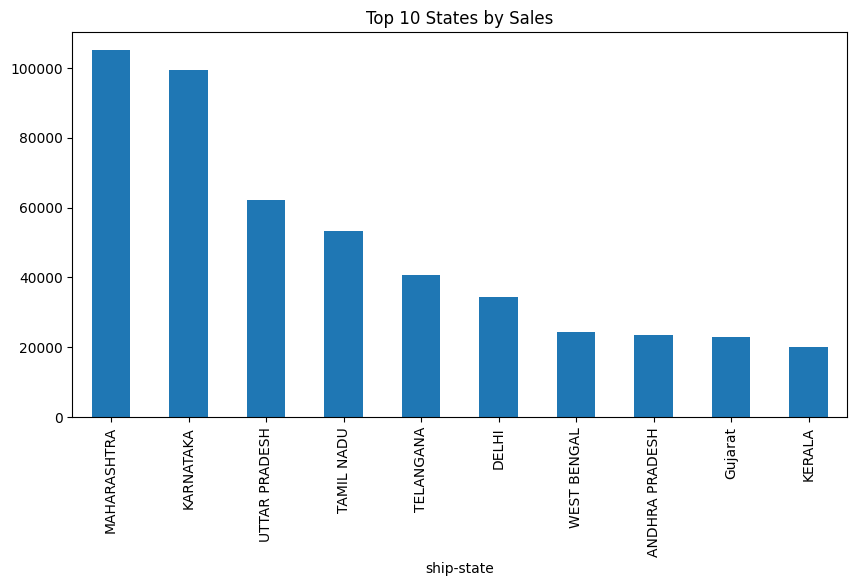

In [20]:
#03: State-wise Sales

state_sales = df.groupby('ship-state')['Amount'].sum().sort_values(ascending=False).head(10)

state_sales.plot(kind='bar', figsize=(10,5), title='Top 10 States by Sales')

<Axes: title={'center': 'Order Status Distribution'}, xlabel='Status'>

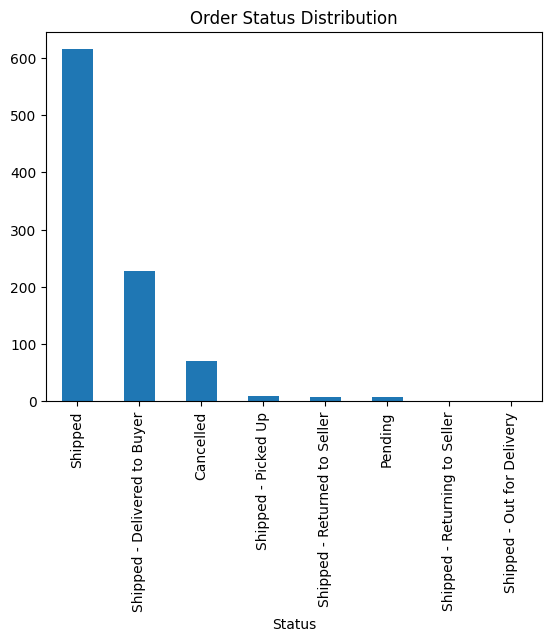

In [21]:
#04: Order Status Analysis

status_counts = df['Status'].value_counts()

status_counts.plot(kind='bar', title='Order Status Distribution')

<Axes: title={'center': 'Sales by Fulfilment'}, xlabel='Fulfilment'>

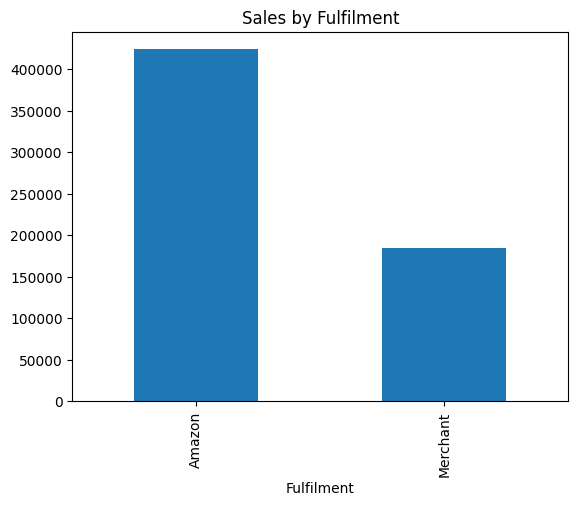

In [22]:
df.groupby('Fulfilment')['Amount'].sum().plot(kind='bar', title='Sales by Fulfilment')

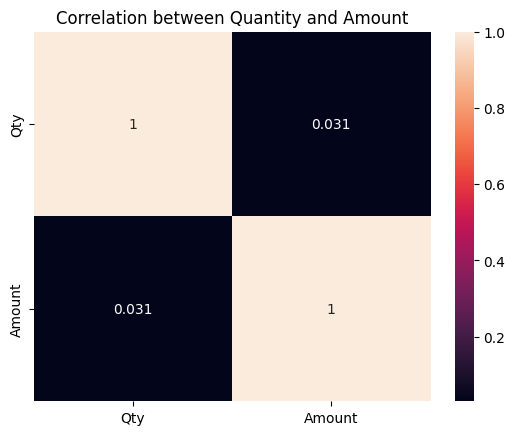

In [ ]:
# Adding a Correlation Insight

import seaborn as sns

sns.heatmap(df[['Qty', 'Amount']].corr(), annot=True)
plt.title('Correlation between Quantity and Amount')
plt.show()

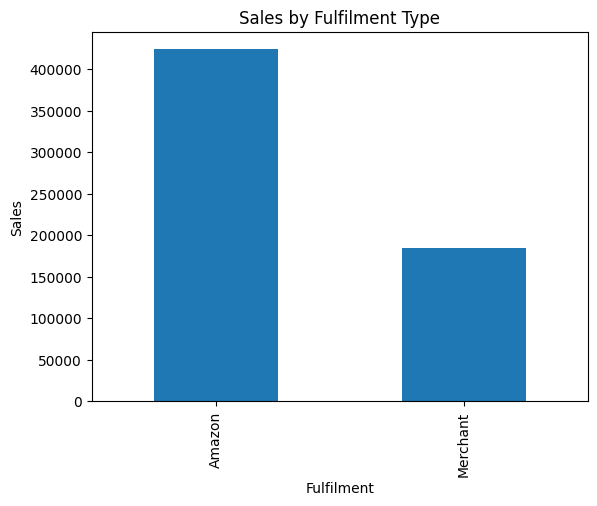

In [ ]:
# Sales by Fulfilment (Business Insight)


df.groupby('Fulfilment')['Amount'].sum().plot(kind='bar')

plt.title('Sales by Fulfilment Type')
plt.xlabel('Fulfilment')
plt.ylabel('Sales')
plt.show()

# Key Insights

# 1. Sales Trend Analysis

Sales showed a strong upward trend and peaked in April 2022, followed by a noticeable decline in the subsequent months. This suggests possible seasonality or reduced demand after a peak period.

# 2. Top Performing Category

The "Set" category generated the highest revenue among all product categories, indicating strong customer preference and consistent demand.

# 3. Regional Performance

Maharashtra emerged as the top-performing state in terms of sales, highlighting a strong customer base and market potential in this region.

# 4. Order Status Distribution

A significant proportion of orders were successfully delivered; however, there are noticeable cancelled and pending orders, which may indicate operational inefficiencies.

# 5. Fulfilment Analysis

Orders fulfilled by Amazon contributed a larger share of total revenue compared to merchant fulfilment, suggesting better efficiency and customer trust.

# 6. Quantity vs Revenue Relationship

A positive correlation exists between order quantity and total sales amount, indicating that higher quantities directly contribute to increased revenue.


# Business Recommendations

* Focus marketing and promotional strategies on high-performing regions such as Maharashtra
* Increase inventory and availability for high-demand categories like "Set"
* Investigate reasons for sales decline after peak months to stabilize revenue
* Improve order fulfilment processes to reduce cancellations and delays
* Leverage Amazon fulfilment channels to maximize sales performance
